<a href="https://colab.research.google.com/github/VadimKaryakin/FractalAnalysis/blob/master/Fractal_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
filename = "12.jpg"
#k - количество кластеров
k = 3

## Фрактальная сигнатура




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from scipy.ndimage import generic_filter
from scipy.stats import linregress

In [ ]:
def fractal_signature(imar, d_=10):
    u = imar.copy()
    b = imar.copy()

    footprint=np.array([[0, 1, 0],
                        [1, 0, 1],
                        [0, 1, 0]])
    ds = range(1, d_)
    vols = []

    for d in ds:
        fst_u = u + 1
        fst_b = b - 1

        scnd_u = maximum_filter(u, mode='constant', footprint=footprint, cval=0)
        scnd_b = minimum_filter(b, mode='constant', footprint=footprint, cval=255)

        u = np.maximum(fst_u, scnd_u)
        b = np.minimum(fst_b, scnd_b)

        vols.append(np.sum(u - b))

    x = -np.log(ds[1:d_-2])
    y = [np.log((vols[i] - vols[i-1])/2) for i in range(1, d_-2)]    
    if (len(x) != len(y)):
      print("Length error")
    return linregress(x, y).slope

In [ ]:
img = cv.imread(filename, cv.IMREAD_GRAYSCALE)
print(img.shape)
#shape[0] - height, shape[1] - width
imar = np.array(img, dtype=np.int16)

(570, 1000)


In [ ]:
from scipy.ndimage.filters import maximum_filter, minimum_filter, generic_filter

In [ ]:
parts = []
eps = 20

for start_y, end_y in zip(range(0, imar.shape[0]-eps, eps), range(eps, imar.shape[0], eps)):
    for start_x, end_x in zip(range(0, imar.shape[1]-eps, eps), range(eps, imar.shape[1], eps)):
        parts.append((start_x, start_y))        
        

In [ ]:
ads26 = []
for part in parts:
  start_x, start_y = part
  ads26.append(fract_signature(imar[start_y:start_y+eps, start_x:start_x+eps], 10))

ads10 = []
eps = 10
for part in parts:
  start_x, start_y = part
  ads10.append(fract_signature(imar[start_y:start_y+eps, start_x:start_x+eps], 10))

In [ ]:
#перевести из одного вектора во множество
if np.array(ads10)[0].size == 1:
  ads10 = np.array(ads10).reshape(-1,1)
  ads26 = np.array(ads26).reshape(-1,1)

ads = np.hstack((ads10, ads26))

In [ ]:
print(ads)

In [ ]:
from pandas import DataFrame
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import preprocessing

X_scaled = preprocessing.scale(ads)
kmeans = KMeans(n_clusters=k).fit(X_scaled)

#shape[0] - height, shape[1] - width
x = [x for (x,y) in parts]
y = [y for (x,y) in parts]

#инвертировать ось y
plt.gca().invert_yaxis()

plt.scatter(x, y, c=kmeans.labels_.astype(float), s=50, alpha=0.5)
plt.savefig('result/signature.png')

##Спектр обобщенных фрактальных размерностей Реньи

In [ ]:
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
from scipy.ndimage.filters import convolve
from scipy.stats import linregress

In [ ]:
def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.299, 0.587, 0.114])

In [ ]:
def reni_entropy(p, q):
    return (1 / (1 - q) * np.log(np.sum(np.power(p, q)))) if q != 1 else (-np.sum(p * np.log(p)))

In [ ]:
def get_reni_dim(immat, q, eps):
    ws = range(1, eps, 3)
    ns = []
    
    for w in ws:
        conv = convolve(immat, np.ones((w, w)), mode='constant')[::w, ::w]
        ns.append(reni_entropy(conv / np.sum(conv), q))
    
    x = -np.log(ws)
    y = ns
    
    return linregress(x, y).slope

In [ ]:
def get_reni_spectre(immat, qs, eps):
    return list(map(lambda x: get_reni_dim(immat, x, eps), qs))

In [ ]:
im = Image.open(filename)
immat = rgb2gray(np.array(im))
#чтобы исключить нулевое значение яркости
immat *= 254/255
immat += 1

In [ ]:
q = np.array(range(-10, 10))
#eps - задает размер блоков arange(0, eps)
eps = 20

In [ ]:
from progressbar import ProgressBar

parts = []
specs20 = []

bar = ProgressBar()

for start_y, end_y in bar(zip(range(0, immat.shape[0]-eps, eps), range(eps, immat.shape[0], eps))):
    for start_x, end_x in zip(range(0, immat.shape[1]-eps, eps), range(eps, immat.shape[1], eps)):
        parts.append((start_x, start_y))        
        specs20.append(get_reni_spectre(immat[start_y:end_y, start_x:end_x], q, eps))

| |                                             #    | 27 Elapsed Time: 0:02:04


In [ ]:
from pandas import DataFrame
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import preprocessing


specs20 = np.array(specs20)
X_scaled = preprocessing.scale(specs20)

kmeans = KMeans(n_clusters=k).fit(X_scaled)

#shape[0] - height, shape[1] - width
x = [x for (x,y) in parts]
y = [y for (x,y) in parts]

#инвертировать ось y
plt.gca().invert_yaxis()

plt.scatter(x, y, c=kmeans.labels_.astype(float), s=50, alpha=0.5)
plt.savefig('result/Renie.png')

##Signature + Renie



/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_data.py:190: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn("Numerical issues were encountered "


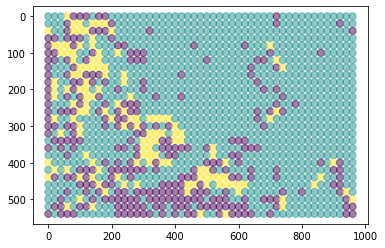

In [ ]:
#specs20
#ads

from sklearn.decomposition import PCA

specs20_scaled = preprocessing.scale(specs20)
ads_scaled = preprocessing.scale(ads)

united_features = np.hstack((specs20_scaled, ads_scaled))

pca = PCA(n_components=8)
principalComponents = pca.fit_transform(united_features)

pca_norm = preprocessing.scale(principalComponents)
kmeans = KMeans(n_clusters=k).fit(pca_norm)

#shape[0] - height, shape[1] - width
x = [x for (x,y) in parts]
y = [y for (x,y) in parts]

#инвертировать ось y
plt.gca().invert_yaxis()

plt.scatter(x, y, c=kmeans.labels_.astype(float), s=50, alpha=0.5)
plt.savefig('result/Signature + Renie.png')

##HSL features



In [ ]:
img = cv.imread(filename)
imgHLS = cv.cvtColor(img, cv.COLOR_BGR2HLS)

##Gray-level co-occurance matrix

In [ ]:
from skimage.feature import greycomatrix, greycoprops
from skimage import data

In [ ]:
img = cv.imread(filename, cv.IMREAD_GRAYSCALE)
imar = np.array(img, dtype=np.int16)

eps = 20
stat_features = []

for start1, end1 in zip(range(0, imar.shape[0]-eps, eps), range(eps, imar.shape[0], eps)):
    for start2, end2 in zip(range(0, imar.shape[1]-eps, eps), range(eps, imar.shape[1], eps)):                
          glcm = greycomatrix(imar[start1:end1, start2:end2], distances=[1], angles=[0], levels=256,
                        symmetric=True, normed=True)
          GLCM_feat = []
          GLCM_feat.append(greycoprops(glcm, 'dissimilarity')[0, 0]) #first parameter - номер в distances
          GLCM_feat.append(greycoprops(glcm, 'correlation')[0, 0])   #second parameter - номер в angles
          GLCM_feat.append(greycoprops(glcm, 'contrast')[0, 0])
          GLCM_feat.append(greycoprops(glcm, 'homogeneity')[0, 0])
          GLCM_feat.append(greycoprops(glcm, 'energy')[0, 0])
          GLCM_feat.append(greycoprops(glcm, 'ASM')[0, 0])
          stat_features.append(GLCM_feat)

In [ ]:
#for part in parts:    
#    glcm = greycomatrix(patch, distances=[5], angles=[0], levels=256,
#                        symmetric=True, normed=True)
#    xs.append(greycoprops(glcm, 'dissimilarity')[0, 0])
#    ys.append(greycoprops(glcm, 'correlation')[0, 0])

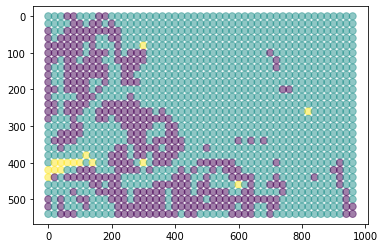

In [ ]:
stat_features = np.array(stat_features)
X_scaled = preprocessing.scale(stat_features)

kmeans = KMeans(n_clusters=k).fit(X_scaled)

#shape[0] - height, shape[1] - width
x = [x for (x,y) in parts]
y = [y for (x,y) in parts]

#инвертировать ось y
plt.gca().invert_yaxis()

plt.scatter(x, y, c=kmeans.labels_.astype(float), s=50, alpha=0.5)
plt.savefig('result/GLCM.png')

## GLCM + signature + Renie

/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_data.py:190: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn("Numerical issues were encountered "


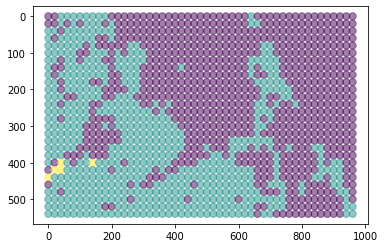

In [ ]:
#specs20
#ads
#stat_features
from sklearn.decomposition import PCA

specs20_scaled = preprocessing.scale(specs20)
ads_scaled = preprocessing.scale(ads)
stat_features_scaled = preprocessing.scale(stat_features)


united_features = np.hstack((specs20_scaled, ads_scaled, stat_features_scaled))

pca = PCA(n_components=14)
principalComponents = pca.fit_transform(united_features)

pca_norm = preprocessing.scale(principalComponents)
kmeans = KMeans(n_clusters=k).fit(pca_norm)

#shape[0] - height, shape[1] - width
x = [x for (x,y) in parts]
y = [y for (x,y) in parts]

#инвертировать ось y
plt.gca().invert_yaxis()



plt.scatter(x, y, c=kmeans.labels_.astype(float), s=50, alpha=0.5)
plt.savefig('result/GLCM + signature + Renie.png')

##GLCM + signature

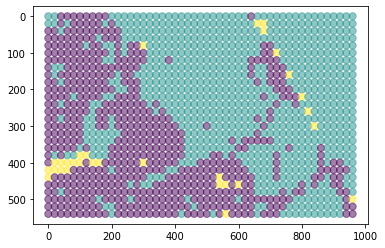

In [ ]:
#specs20
#ads
#stat_features

ads_scaled = preprocessing.scale(ads)
stat_features_scaled = preprocessing.scale(stat_features)

united_features = np.hstack((ads_scaled, stat_features_scaled))

pca = PCA(n_components=8)
principalComponents = pca.fit_transform(united_features)

pca_norm = preprocessing.scale(principalComponents)
kmeans = KMeans(n_clusters=k).fit(pca_norm)

#shape[0] - height, shape[1] - width
x = [x for (x,y) in parts]
y = [y for (x,y) in parts]

#инвертировать ось y
plt.gca().invert_yaxis()

plt.scatter(x, y, c=kmeans.labels_.astype(float), s=50, alpha=0.5)
plt.savefig('result/GLCM + signature.png')

##GLCM + Renie

/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_data.py:190: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn("Numerical issues were encountered "


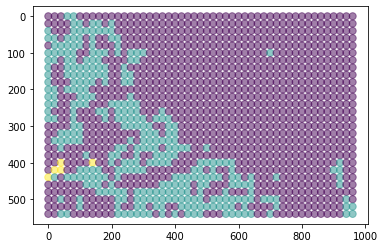

In [ ]:
#specs20
#ads
#stat_features
from sklearn.decomposition import PCA

specs20_scaled = preprocessing.scale(specs20)
stat_features_scaled = preprocessing.scale(stat_features)


united_features = np.hstack((specs20_scaled, stat_features_scaled))

pca = PCA(n_components=8)
principalComponents = pca.fit_transform(united_features)

pca_norm = preprocessing.scale(principalComponents)
kmeans = KMeans(n_clusters=k).fit(pca_norm)

#shape[0] - height, shape[1] - width
x = [x for (x,y) in parts]
y = [y for (x,y) in parts]

#инвертировать ось y
plt.gca().invert_yaxis()



plt.scatter(x, y, c=kmeans.labels_.astype(float), s=50, alpha=0.5)
plt.savefig('result/GLCM + Renie.png')

##Признаки Харалика


In [ ]:
!zip -r /content/result.zip /content/result

updating: content/result/ (stored 0%)
updating: content/result/GLCM.png (deflated 1%)
updating: content/result/.ipynb_checkpoints/ (stored 0%)
updating: content/result/Renie.png (deflated 1%)
updating: content/result/Signature + Renie.png (deflated 1%)
updating: content/result/GLCM + Renie.png (deflated 1%)
updating: content/result/GLCM + signature.png (deflated 1%)
updating: content/result/signature.png (deflated 0%)
updating: content/result/GLCM + signature + Renie.png (deflated 1%)


In [ ]:
from google.colab import files
files.download("/content/result.zip")